# **Bondad de ajuste** 

Las pruebas de bondad de ajuste son pruebas de hipótesis utilizadas para determinar qué tan bien un conjunto de datos se ajusta a una distribución teórica específica. Estas pruebas son fundamentales en estadística para validar modelos y suposiciones sobre los datos. 

En la literatura, usualmente se utiliza el término **Distribución subyacente** para referirse a la distribución "real" de los datos, sin embargo **jamás se conocerá con certeza esta distribución**, solo podemos suponer cierta una distribución que no tenga suficiente evidencia en contra.




Supongamos que tenemos un conjunto de datos y queremos ajustar una distribución. Idealmente, antes de intentar ajustar una distribución, se debe entender la naturaleza de los datos y el fenómeno que representan. Esto puede ayudar a seleccionar distribuciones candidatas apropiadas para el ajuste. 

Algunos aspectos a considerar al momento de proponer distribuciones son:

- La escala de los datos (categóricos o numéricos).
- El soporte de los datos (si son positivos, negativos, discretos).
- La forma de la distribución observada (asimetría, curtosis, presencia de colas pesadas, etc.).


Por ejemplo, en el área de Seguros, los montos de reclamaciones  (**severidad**) suelen modelarse con distribuciones como la Log-Normal o la Weibull (que son continuas y positivas), mientras que el número de reclamaciones (**frecuencia**) pueden modelarse con distribuciones discretas como la Poisson o la Binomial Negativa.



A continuación, se describen algunas herramientas computacionales de utilidad cuando se busca ajustar una distribución a un conjunto de datos.

In [ ]:
set.seed(123)

library(fitdistrplus)
library(vcd)
library(ggplot2)
library(dplyr)

## Herramientas gráficas

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  10.00   50.00   79.00   73.65  100.00  200.00 

'data.frame':	254 obs. of  1 variable:
 $ serving: num  30 10 20 24 20 24 40 20 50 30 ...


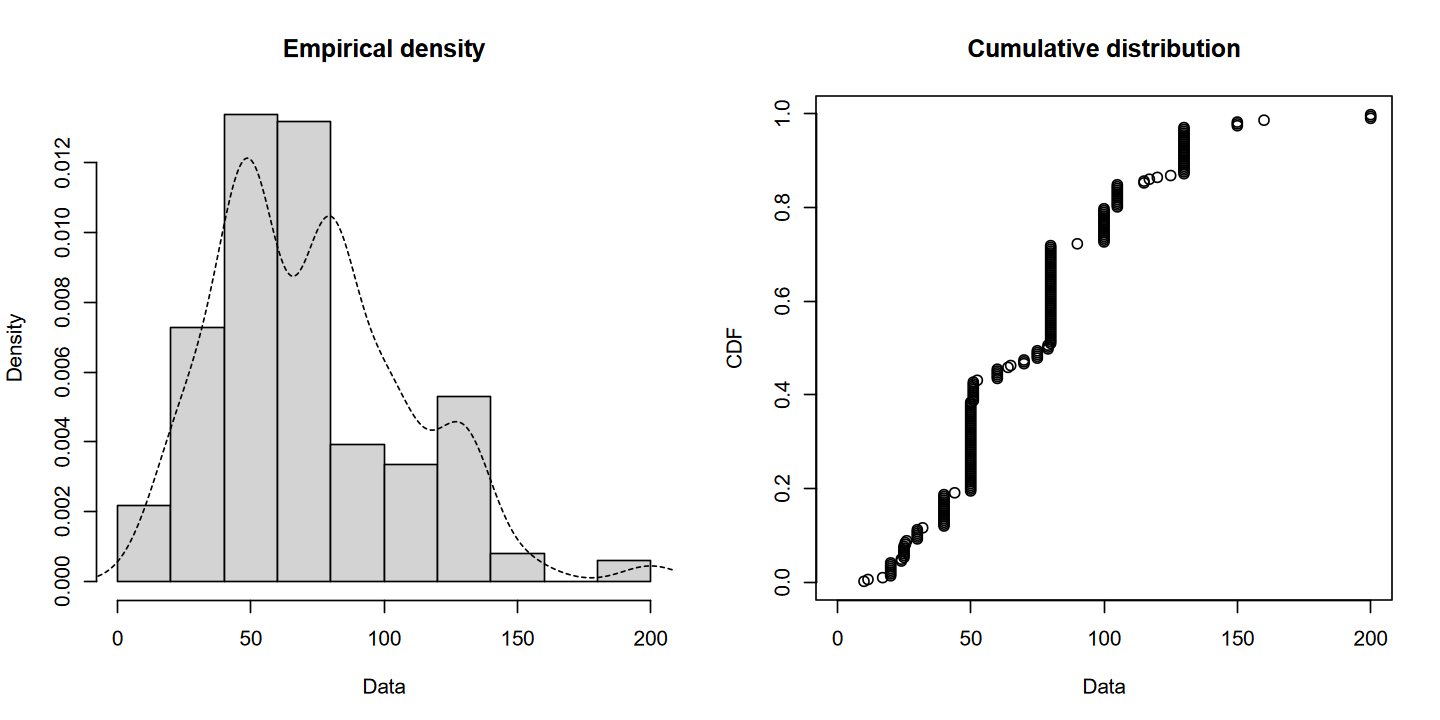

In [2]:
data("groundbeef",package = "fitdistrplus")


# configuuracion para que las dimensiones del grafico sean mejores
par(mfrow=c(1,1), fig=c(0,1,0,0.8), mar=c(5,4,4,2))
options(repr.plot.width=12, repr.plot.height=6)



#funcion para graficar la distribucion "empirica" de los datos
plotdist(groundbeef$serving, histo = TRUE,demp = TRUE)

summary(groundbeef$serving)
str(groundbeef)

Algunas observaciones iniciales:

- Valores positivos.
- Soporte discreto o continuo.
- Posiblemente distribución multimodal.
- Sesgo a la derecha (asimetría positiva).
- Colas ligeras.



Luego de una visualización inicial de los datos, además de calcular estadísticas descriptivas, podemos proponer algunas distribuciones para ajustar los datos.



Fitting of the distribution ' norm ' by maximum likelihood 
Parameters : 
     estimate Std. Error
mean 73.64567   2.247180
sd   35.81416   1.588996
Loglikelihood:  -1269.31   AIC:  2542.619   BIC:  2549.694 
Correlation matrix:
     mean sd
mean    1  0
sd      0  1


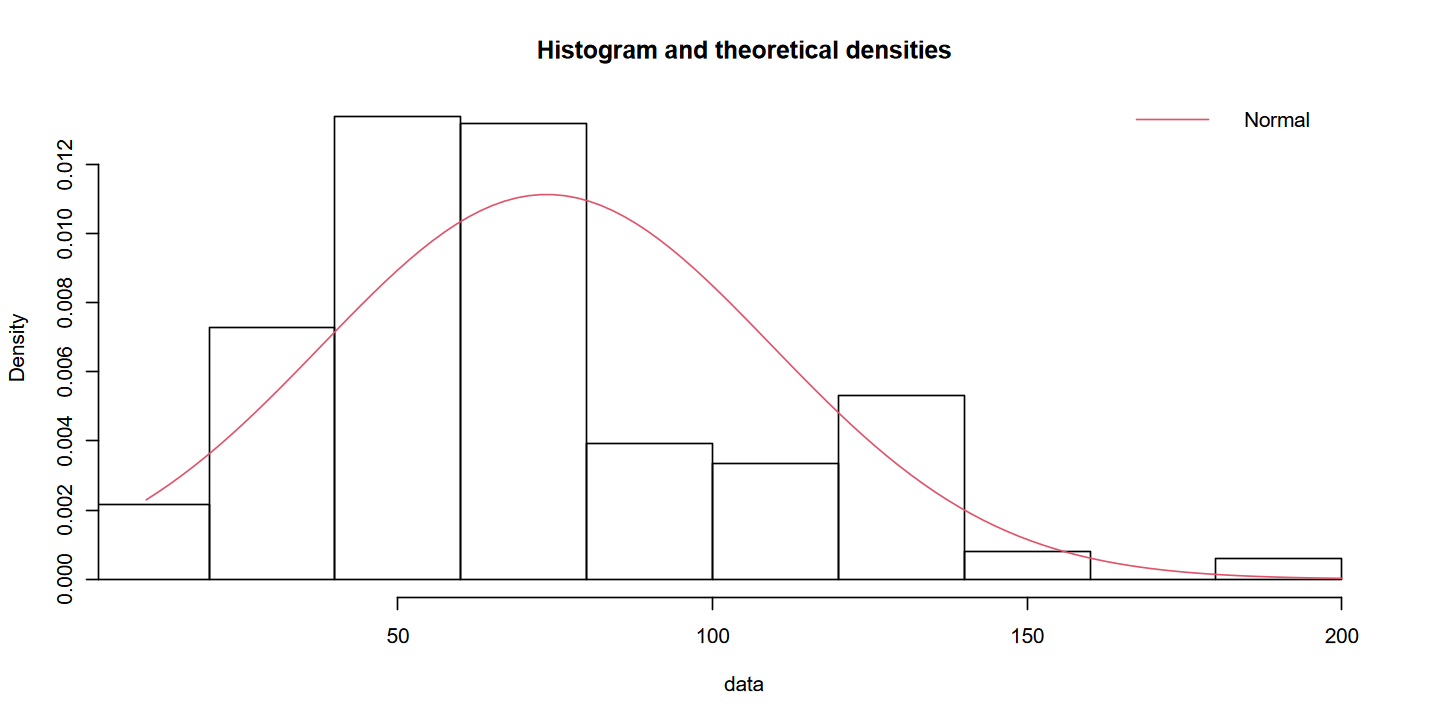

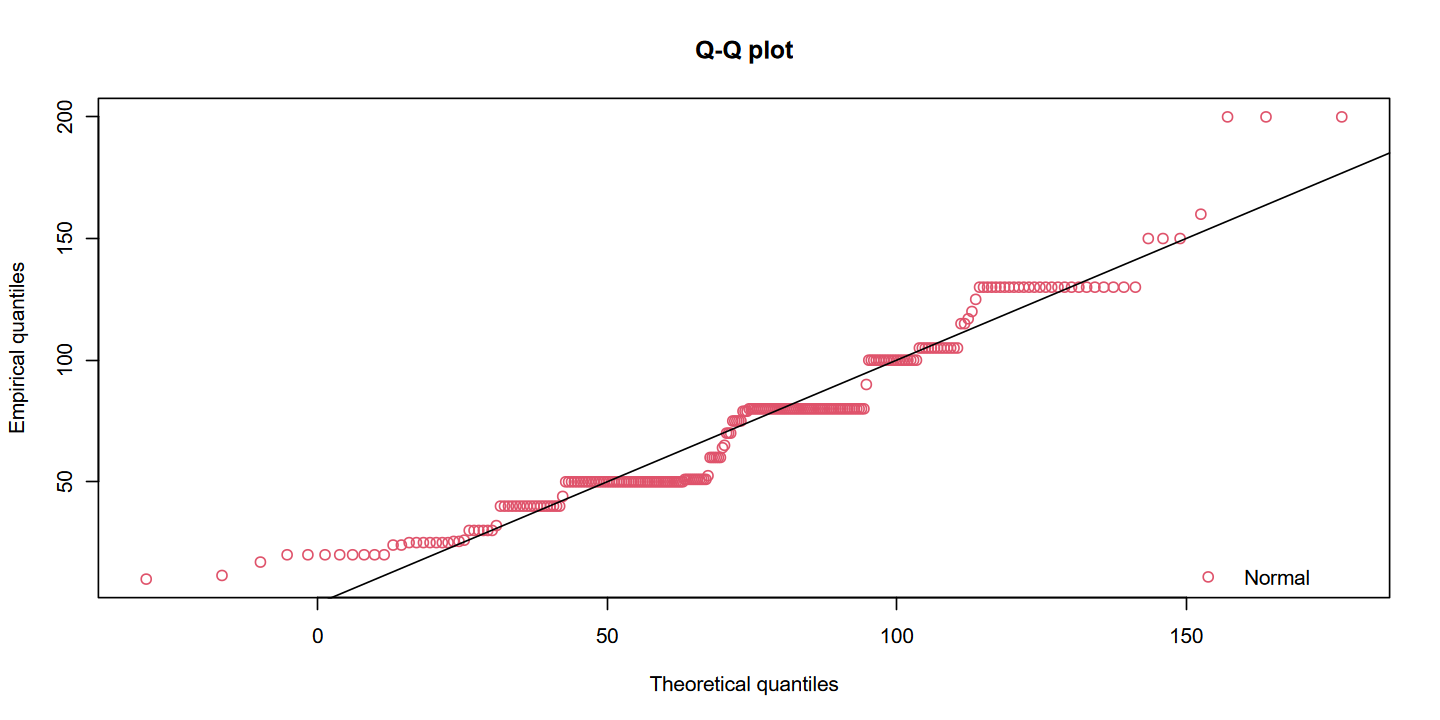

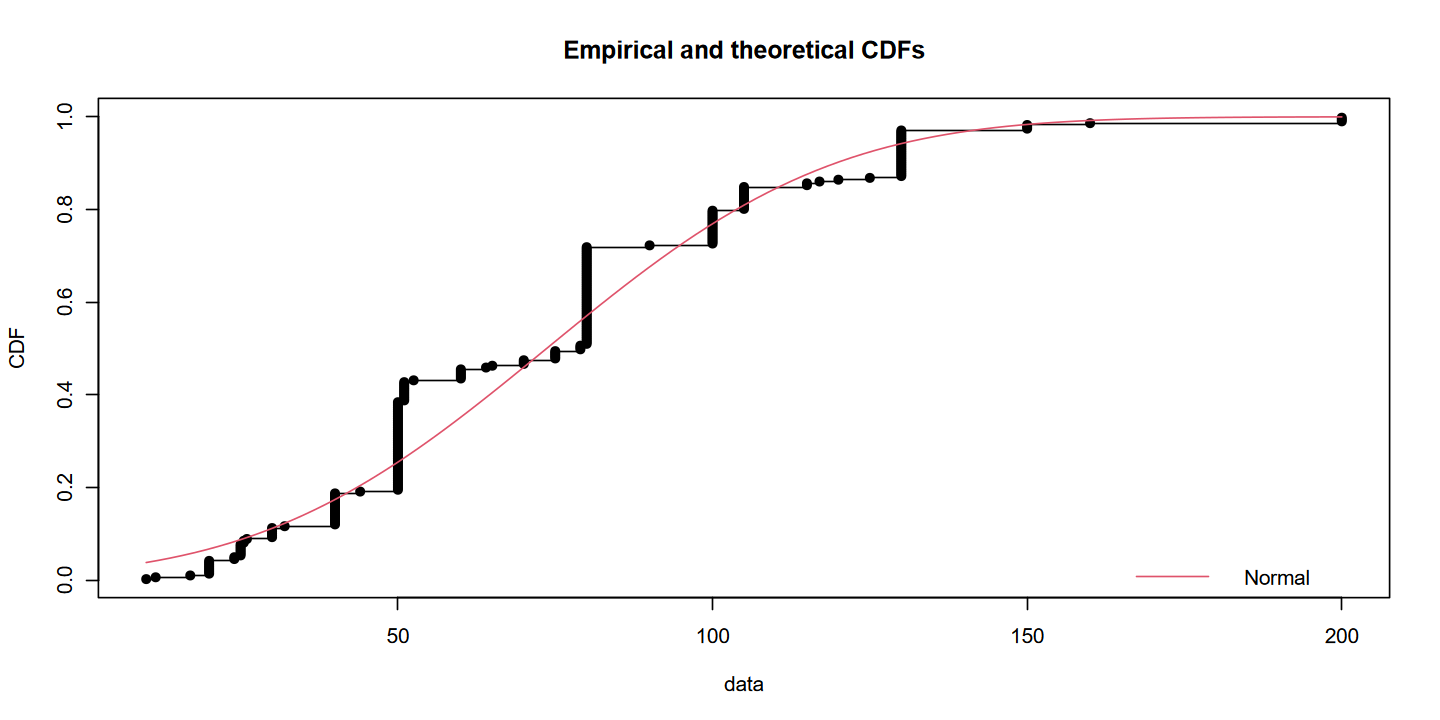

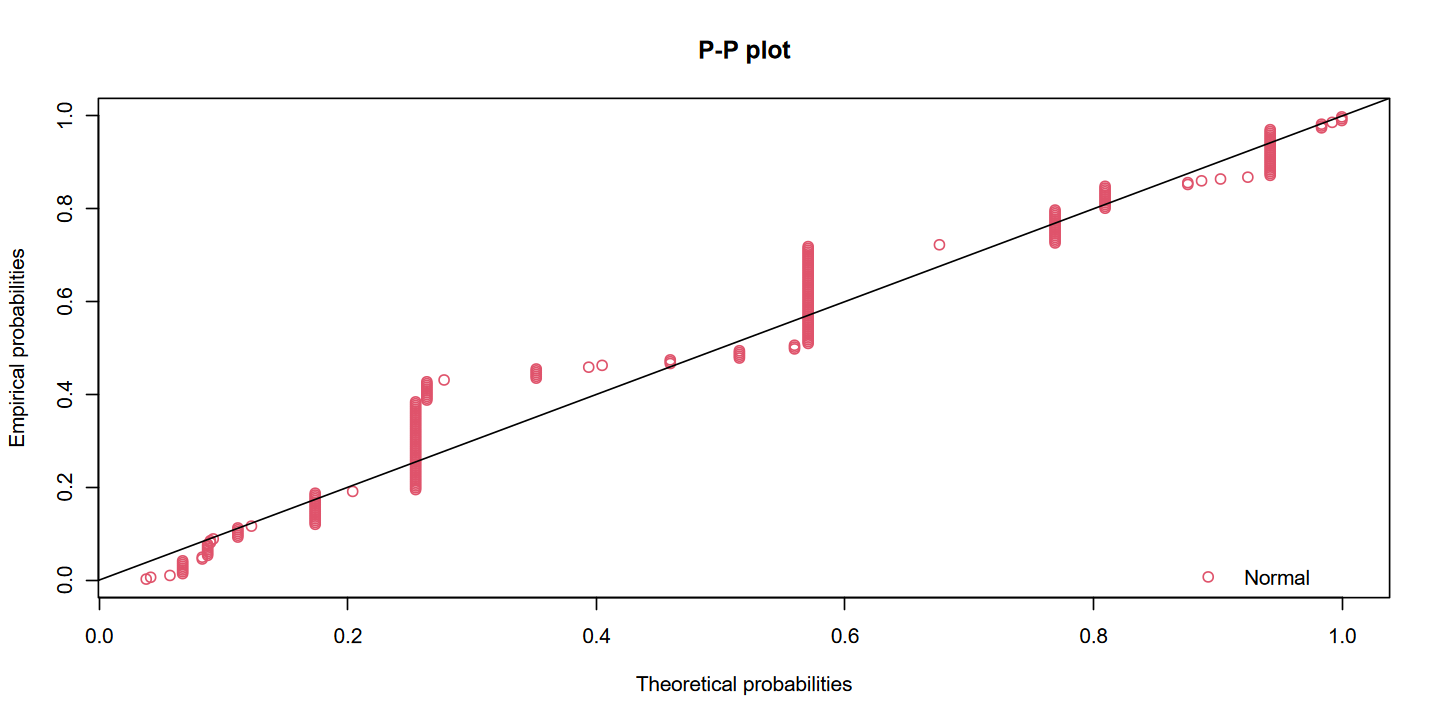

In [3]:
modelo_norm <- fitdist(groundbeef$serving, "norm") # una normal para datos solo positivos?? 

summary(modelo_norm)

plot.legend <- c("Normal")
denscomp(modelo_norm, legendtext = plot.legend)
qqcomp(modelo_norm, legendtext = plot.legend)
cdfcomp(modelo_norm, legendtext = plot.legend)
ppcomp(modelo_norm, legendtext = plot.legend)




También es posible proponer varias distribuciones y comparar de forma gráfica cuál de ellas se ajusta mejor a los datos observados, esto como un complemento a las pruebas de bondad de ajuste, que son las herramientas estadísticas formales para evaluar el ajuste de una distribución a los datos.

Fitting of the distribution ' gamma ' by maximum likelihood 
Parameters : 
        estimate  Std. Error
shape 4.00955898 0.341451640
rate  0.05443907 0.004937239
Loglikelihood:  -1253.625   AIC:  2511.25   BIC:  2518.325 
Correlation matrix:
          shape      rate
shape 1.0000000 0.9384578
rate  0.9384578 1.0000000


Fitting of the distribution ' lnorm ' by maximum likelihood 
Parameters : 
         estimate Std. Error
meanlog 4.1693701 0.03366988
sdlog   0.5366095 0.02380783
Loglikelihood:  -1261.319   AIC:  2526.639   BIC:  2533.713 
Correlation matrix:
        meanlog sdlog
meanlog       1     0
sdlog         0     1


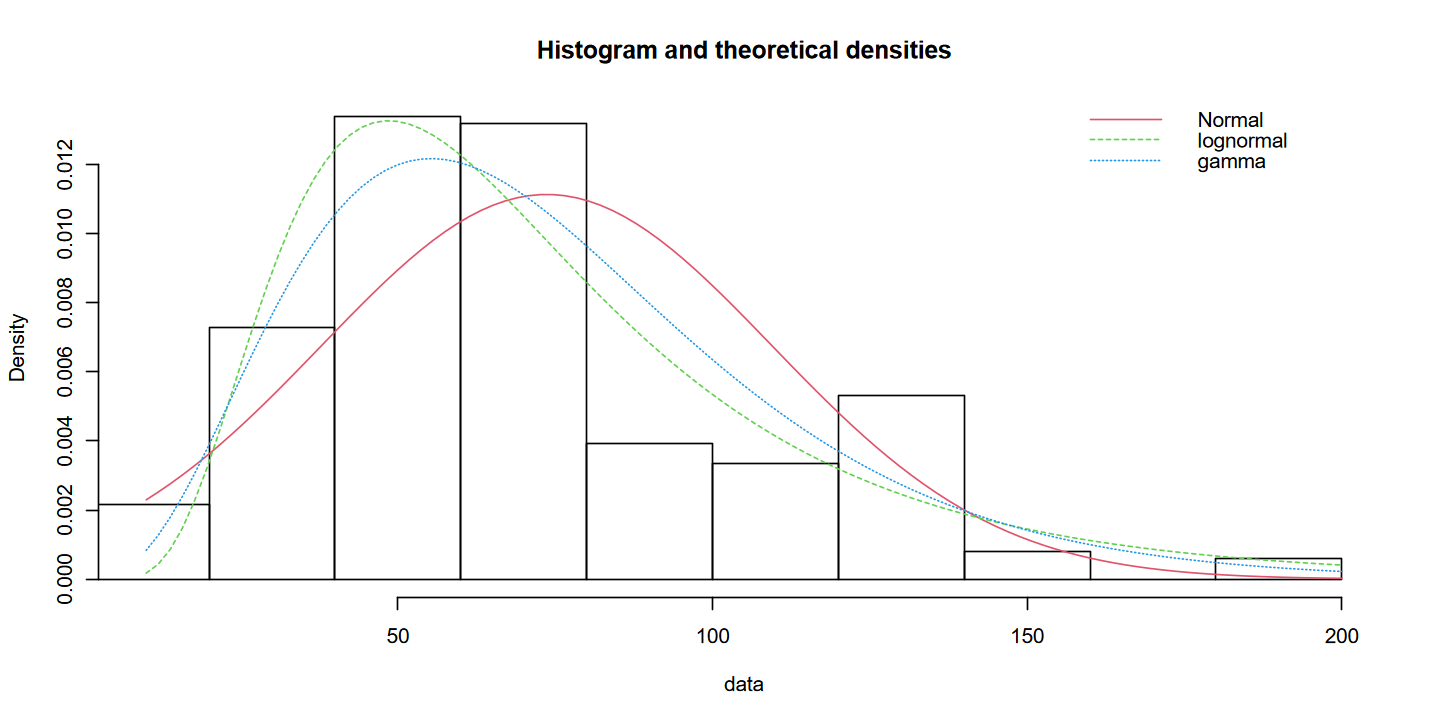

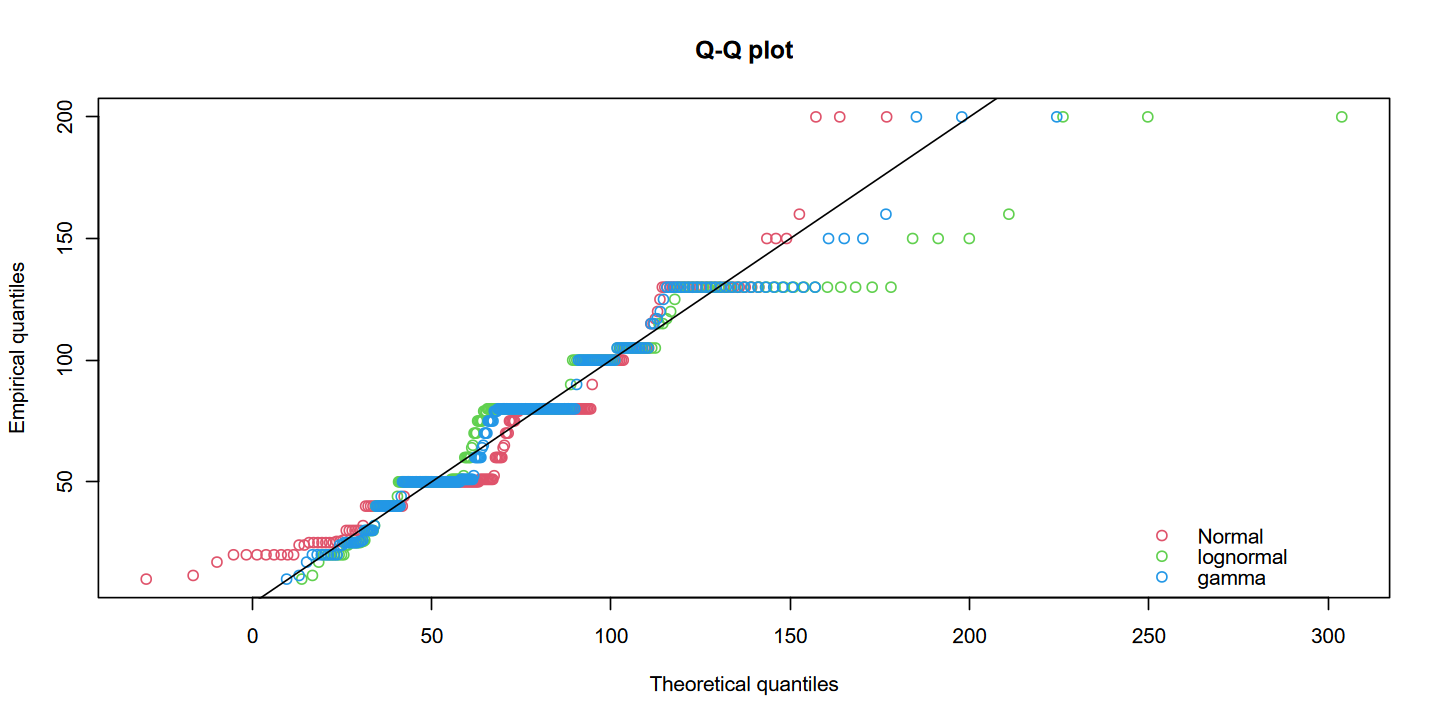

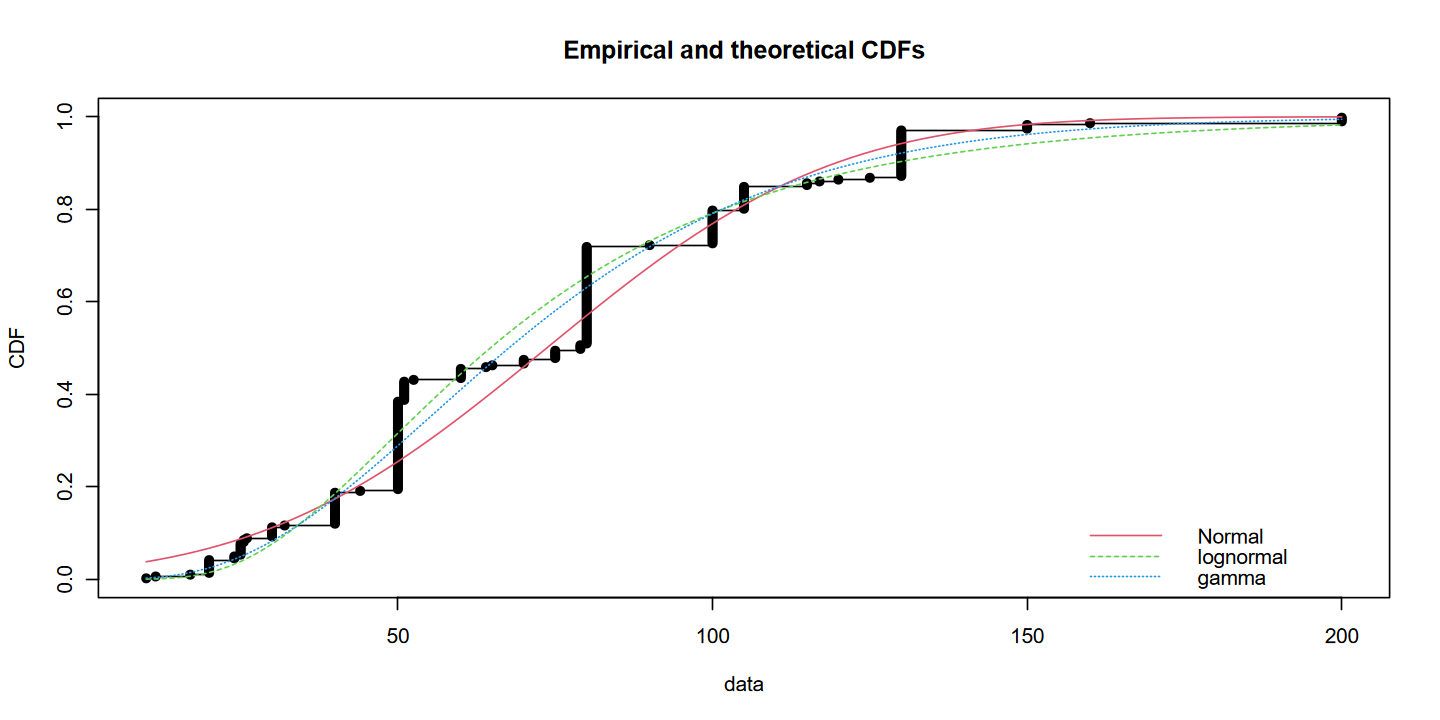

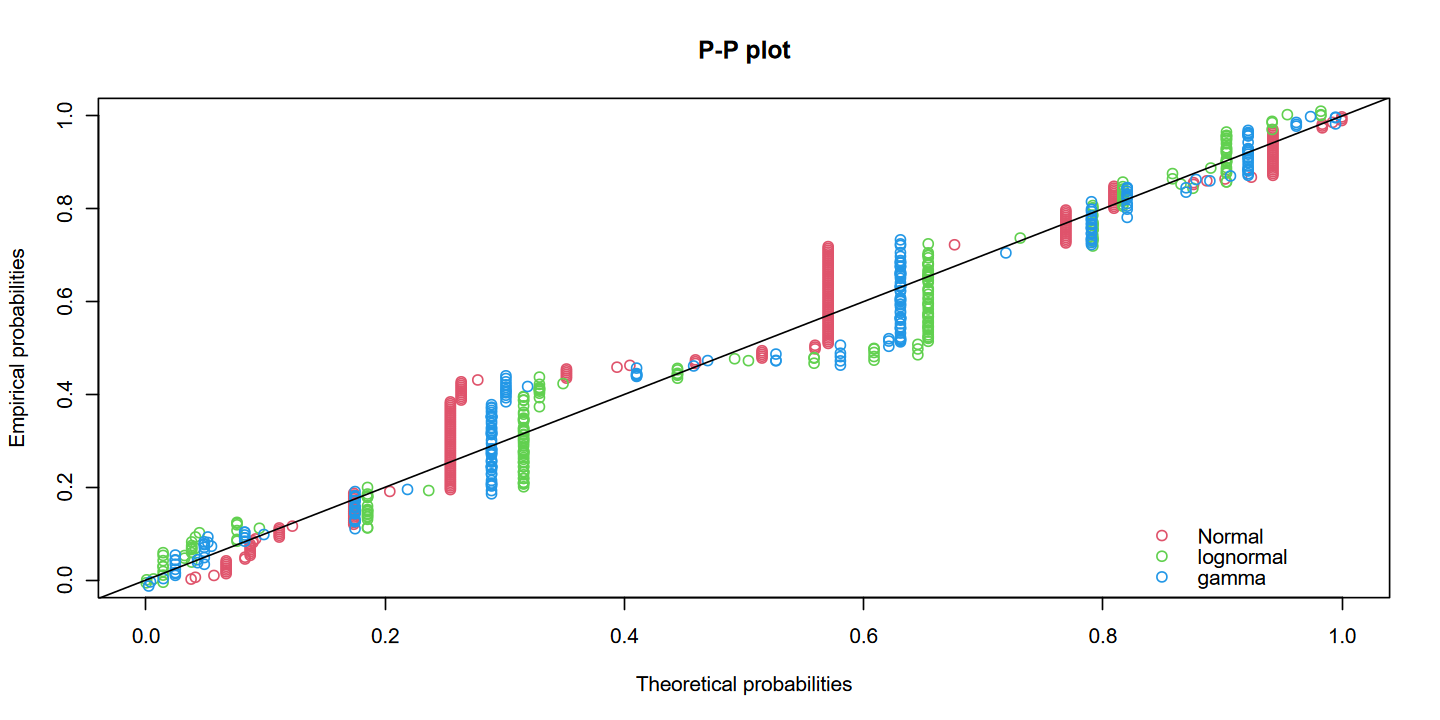

In [4]:
#defininmos otros modelos para comparar
modelo_gamma <- fitdist(groundbeef$serving, "gamma")
modelo_lnorm <- fitdist(groundbeef$serving, "lnorm")


summary(modelo_gamma, digits = digits, maxsum = maxsum)
summary(modelo_lnorm, digits = digits, maxsum = maxsum)

#leyenda
plot.legend <- c("Normal", "lognormal", "gamma")

denscomp(list(modelo_norm, modelo_lnorm, modelo_gamma), legendtext = plot.legend)
qqcomp(list(modelo_norm, modelo_lnorm, modelo_gamma), legendtext = plot.legend)
cdfcomp(list(modelo_norm, modelo_lnorm, modelo_gamma), legendtext = plot.legend)
ppcomp(list(modelo_norm, modelo_lnorm, modelo_gamma), legendtext = plot.legend)

Otra alternativa es aprovechar la caracterización del las distribuciones a través de su asimetría y curtosis, al comparar los momentos muestrales con los momentos teóricos de las distribuciones propuestas. Sin embargo, esta aproximación puede ser limitada, ya que diferentes distribuciones pueden compartir los mismos momentos hasta cierto orden, lo que podría llevar a conclusiones erróneas sobre el ajuste.

summary statistics
------
min:  10   max:  200 
median:  79 
mean:  73.64567 
estimated sd:  35.88487 
estimated skewness:  0.7352745 
estimated kurtosis:  3.551384 

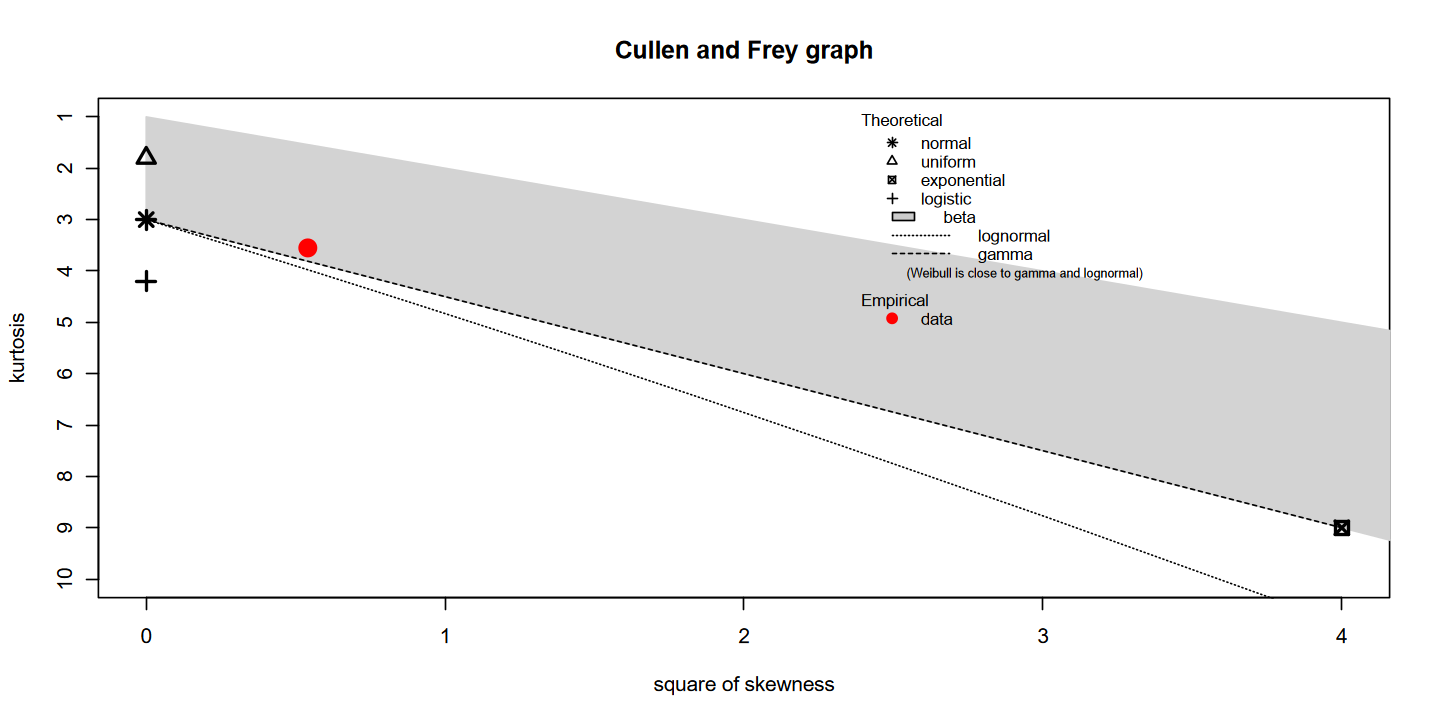

In [ ]:
#funcion que propone distribuciones a partir de las caracteristicas de los datos, compara los momentos
descdist(groundbeef$serving)

## Pruebas de bondad de ajuste

Luego de un análisis gráfico preliminar, se pueden aplicar pruebas de bondad de ajuste para evaluar si hay suficiente evidencia en contra de suponer que los datos observados provienen de una distribución propuesta.

Posteriormente, profundizaremos en otras métricas que permiten comparar varios ajustes realizados a un mismo conjunto de datos, como el AIC (Akaike's Information Criterion) y BIC (Bayesian Information Criterion). Intuitivamente, estas métricas contemplan la Log-Verosimilitud, y penalizan la complejidad del modelo para evitar el sobreajuste. En ambas buscamos que el valor sea lo más bajo posible.


In [6]:
pba <- gofstat(list(modelo_norm, modelo_gamma, modelo_lnorm), 
        fitnames = c("Normal","Gamma","Lognormal"))

pba        

Goodness-of-fit statistics
                                Normal     Gamma Lognormal
Kolmogorov-Smirnov statistic 0.1655419 0.1281486 0.1493090
Cramer-von Mises statistic   0.9449019 0.6936274 0.8277358
Anderson-Darling statistic   5.2955539 3.5672625 4.5436542

Goodness-of-fit criteria
                                 Normal    Gamma Lognormal
Akaike's Information Criterion 2542.619 2511.250  2526.639
Bayesian Information Criterion 2549.694 2518.325  2533.713

La función `gofstat()` no incluye los p-values de las pruebas de bondad de ajuste, pero podemos obtenerlos utilizando las funciones específicas para cada prueba. A continuación, se muestran ejemplos de cómo obtener los resultados de las pruebas de Kolmogorov-Smirnov, Anderson-Darling y Cramér-von Mises:

```R

In [8]:
print("Resultados de prueba KS")
pba$kstest


print("Resultados de prueba AD")
pba$adtest

print("Resultados de prueba CvM")
pba$cvmtest

[1] "Resultados de prueba KS"


Normal      Gamma  Lognormal 
"rejected" "rejected" "rejected"

[1] "Resultados de prueba AD"


Normal          Gamma      Lognormal 
"not computed"     "rejected" "not computed"

[1] "Resultados de prueba CvM"


Normal          Gamma      Lognormal 
"not computed"     "rejected" "not computed"

### Libreria alternativa: `vcd`

Para realizar pruebas de bondad de ajuste en R, una librería alternativa es `vcd` (Visualizing Categorical Data). Esta librería proporciona funciones para realizar pruebas de bondad de ajuste, especialmente útiles para datos categóricos.


	 Goodness-of-fit test for poisson distribution

                      X^2 df     P(> X^2)
Likelihood Ratio 75.86477  9 1.066356e-12


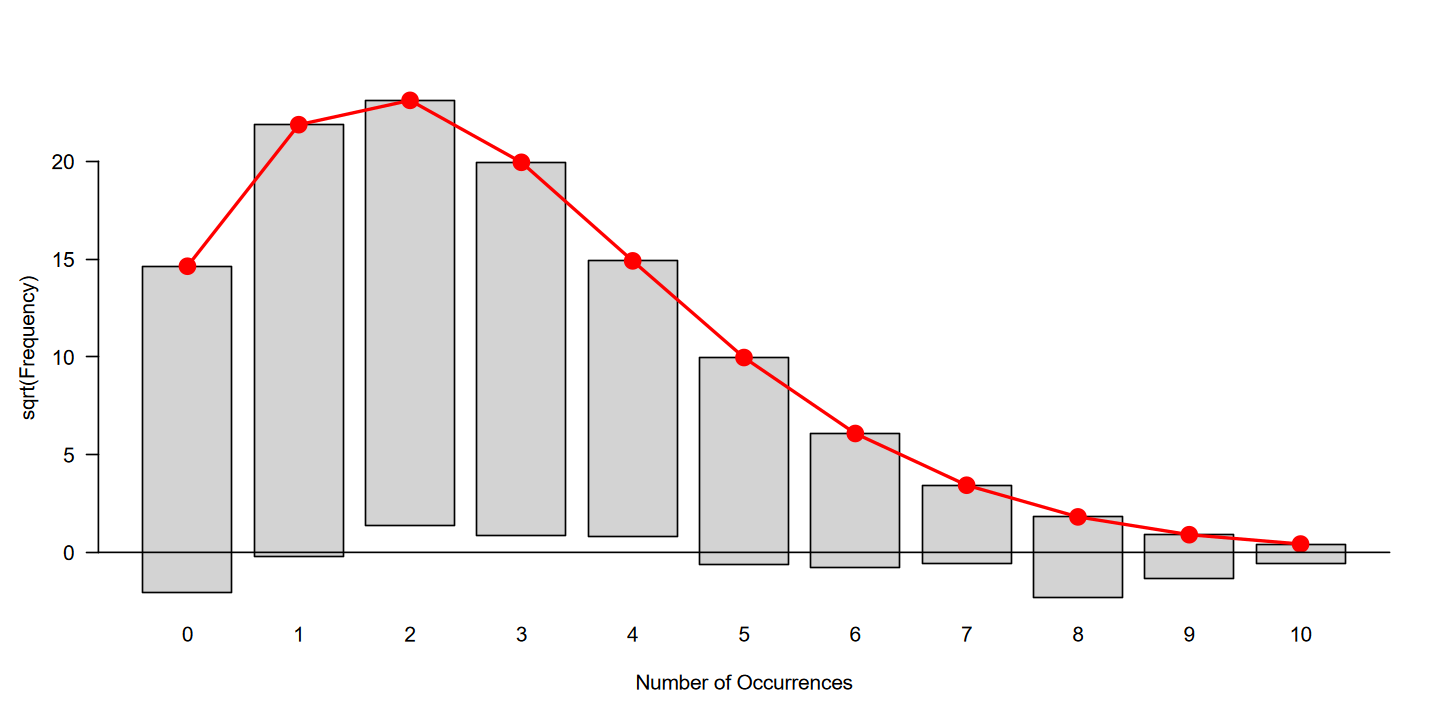

In [ ]:


muestra_pois1 <- rpois(n=1000, lambda=1.5)
muestra_pois2 <- rpois(n=1000, lambda=3)

muestra_pois <- c(muestra_pois1, muestra_pois2)


modelo_pois <-goodfit(muestra_pois, type="poisson")


#realiza prueba Ji cuadrada para los datos
summary(modelo_pois)


#grafica las discrepancias entre los datos y el modelo ajustado
plot(modelo_pois)



## Una consideración importante: Población heterogénea

En ocasiones, cuando se busca ajustar una distribución a un conjunto de datos, puede suceder que ninguna de las distribuciones propuestas se ajuste adecuadamente a los datos observados. En estos casos, es crucial reconocer si hay un factor externo que está metiendo ruido a nuestros datos, por ejemplo:

- Datos atípicos o outliers.
- Errores en el diseño de la medición.
- Poblaciones mezcladas (heterogeneidad en los datos).

Concentrandonos en el último punto, si los datos provienen de una población heterogénea, es posible que ninguna distribución simple se ajuste bien a los datos. Antes de intentar ajustar distribuciones (o modelos) más complejas, es recomendable **investigar si los datos pueden segmentarse en subgrupos más homogéneos**. Esto puede implicar realizar análisis exploratorios adicionales, para identificar posibles subpoblaciones dentro de los datos que simplifiquen el ajuste de distribuciones.


Identificar una segmentación adecuada no siempre es sencillo, y **puede requerir un conocimiento profundo del contexto del problema** y de los datos. 

No bastará con que la segmentación mejore el ajuste de las distribuciones, sino que **debe tener sentido desde el punto de vista del fenómeno que se está estudiando**.

Evidentemente, se puede apreciar mediante visualizaciones si la segmentación mejora el ajuste de las distribuciones, pero también se pueden aplicar pruebas de hipotésis para identificar si las subpoblaciones son significativamentes diferentes entre sí. Para ello, haremos uso de pruebas no paramétricas como la prueba Man-Whitney y la prueba Kruskal-Wallis. 

### Ejemplo: Modelando la presión arterial sistólica

Supongamos que formamos parte de un grupo de investigación dedicado a estudiar el impacto de algunos factores en la presión arterial. En el estudio participaron 90 voluntarios y se tiene el registro de 3 variables: Presión arterial, si la persona es diabética o no y el nivel de actividad física que realiza a la semana.  


Podemos identificar con facilidad que las variables disponibles son de distinta naturaleza, en particular, la variable presión arterial es continua y positiva, mientras que la variable diabético es categórica nominal (Diabetes y No Diabetes) y la variable nivel de actividad física es categórica ordinal (Bajo, Moderado y Alto).

El objetivo, en principio, es **ajustar** una distribución a la variable presión arterial sistólica.




Un primer acercamiento a los datos ...

In [2]:
datos <- read.csv("presion_arterial.csv")

str(datos)

head(datos)


'data.frame':	90 obs. of  3 variables:
 $ Presion_Arterial: int  145 144 146 143 147 130 129 131 128 132 ...
 $ Diabetes        : chr  "Diabetico" "Diabetico" "Diabetico" "Diabetico" ...
 $ Nivel_Actividad : chr  "Bajo" "Moderado" "Alto" "Bajo" ...


,Presion_Arterial,Diabetes,Nivel_Actividad
,<int>,<chr>,<chr>
1,145,Diabetico,Bajo
2,144,Diabetico,Moderado
3,146,Diabetico,Alto
4,143,Diabetico,Bajo
5,147,Diabetico,Moderado
6,130,No_Diabetico,Alto


Por el contexto del problema, es razonable suponer que la presión arterial sistólica tendrá una comportamiento diferente entre personas con mejores hábitos de vida y personas con peores hábitos de vida, al visualizar la distribución de la presión arterial sistólica sin segmentar es evidente que se trata de una población heterogénea, y por lo tanto, no es posible ajustar una distribución simple a los datos.




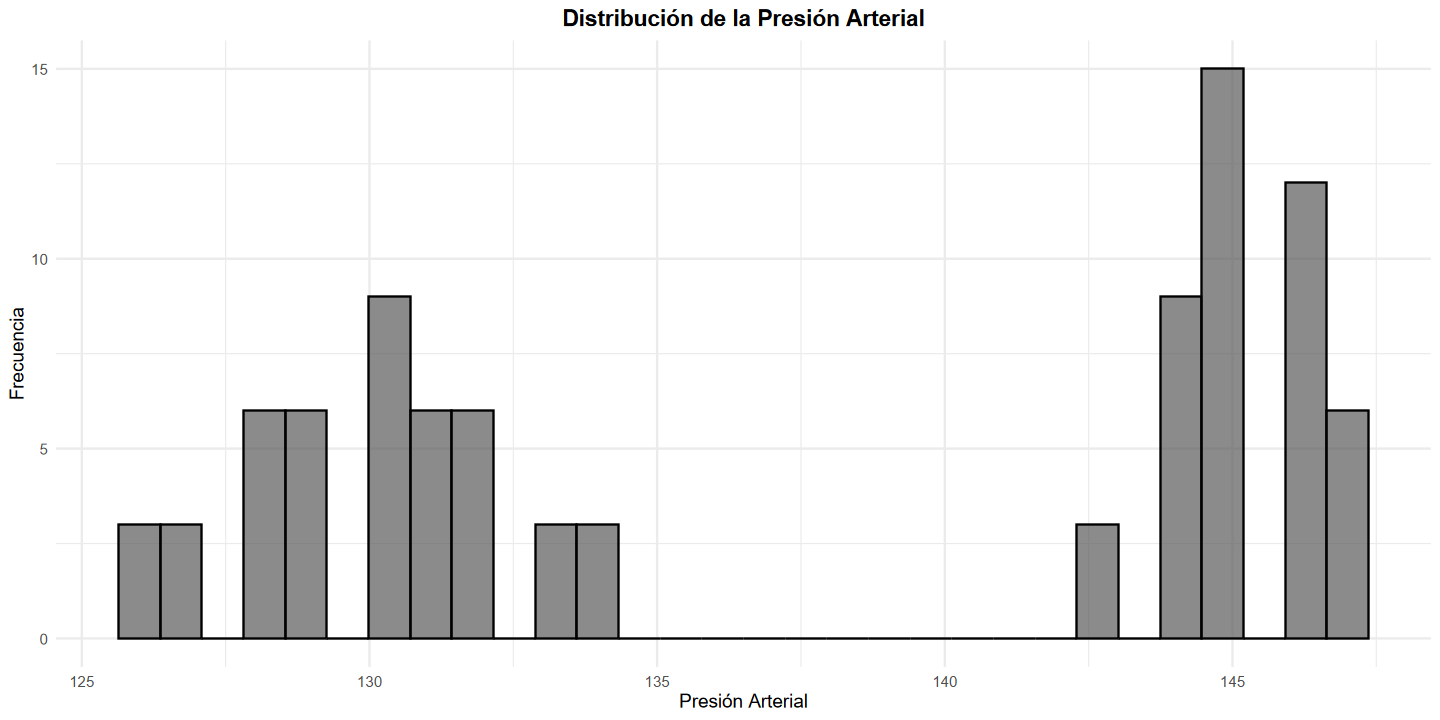

In [24]:

ggplot(datos, aes(x = Presion_Arterial)) +
  geom_histogram(color = "black", bins = 30, alpha = 0.7, position = "identity") +
  labs(
    title = "Distribución de la Presión Arterial",
    x = "Presión Arterial",
    y = "Frecuencia"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5),
    legend.position = "top"
  )


Sin embargo, encontrar una segmentación adecuada puede ser complicado. En este caso, se puede considerar segmentar los datos según el nivel de actividad física de las personas (Bajo, Medio, Alto). Parece no haber una diferencia significativa entre los grupos al visualizar las distribuciones de la presión arterial sistólica segmentadas por nivel de actividad física.

Cuando se consulta con un experto en el área de salud, este explica que la variable nivel de actividad física no es un buen indicador para segmentar la población, ya que una persona puede tener un nivel de actividad física alto, pero tener malos hábitos alimenticios, lo que impacta negativamente en la presión arterial. 

 

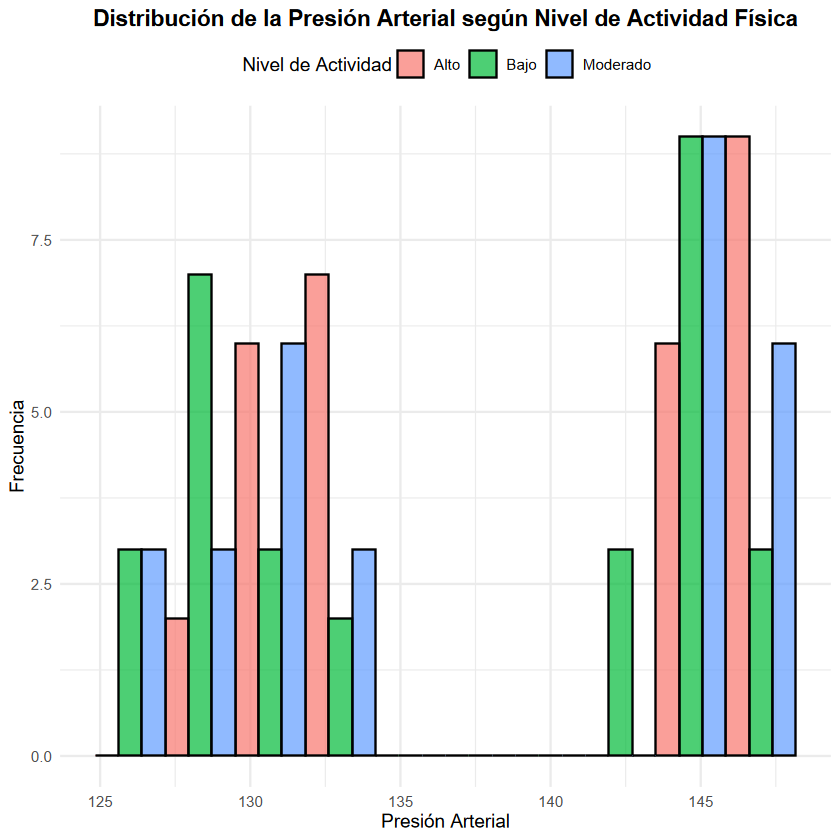

In [6]:

ggplot(datos, aes(x = Presion_Arterial, fill = Nivel_Actividad)) +
  geom_histogram(color = "black", bins = 10, alpha = 0.7, position = "dodge") +
  labs(
    title = "Distribución de la Presión Arterial según Nivel de Actividad Física",
    x = "Presión Arterial",
    y = "Frecuencia",
    fill = "Nivel de Actividad"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5),
    legend.position = "top"
  )


Confirmamos con la prueba de Kruskal-Wallis que no hay diferencias significativas entre los grupos segmentados por nivel de actividad física.

In [7]:
kruskal.test(Presion_Arterial ~ Nivel_Actividad, data = datos)


	Kruskal-Wallis rank sum test

data:  Presion_Arterial by Nivel_Actividad
Kruskal-Wallis chi-squared = 3.1566, df = 2, p-value = 0.2063


En cambio, el experto sugiere que la variable diabético es un mejor indicador para segmentar la población, ya que la diabetes está fuertemente relacionada con la hipertensión, lo que impacta directamente en la presión arterial sistólica. Al visualizar las distribuciones de la presión arterial sistólica segmentadas por la variable diabético, se puede apreciar una diferencia significativa entre los grupos.

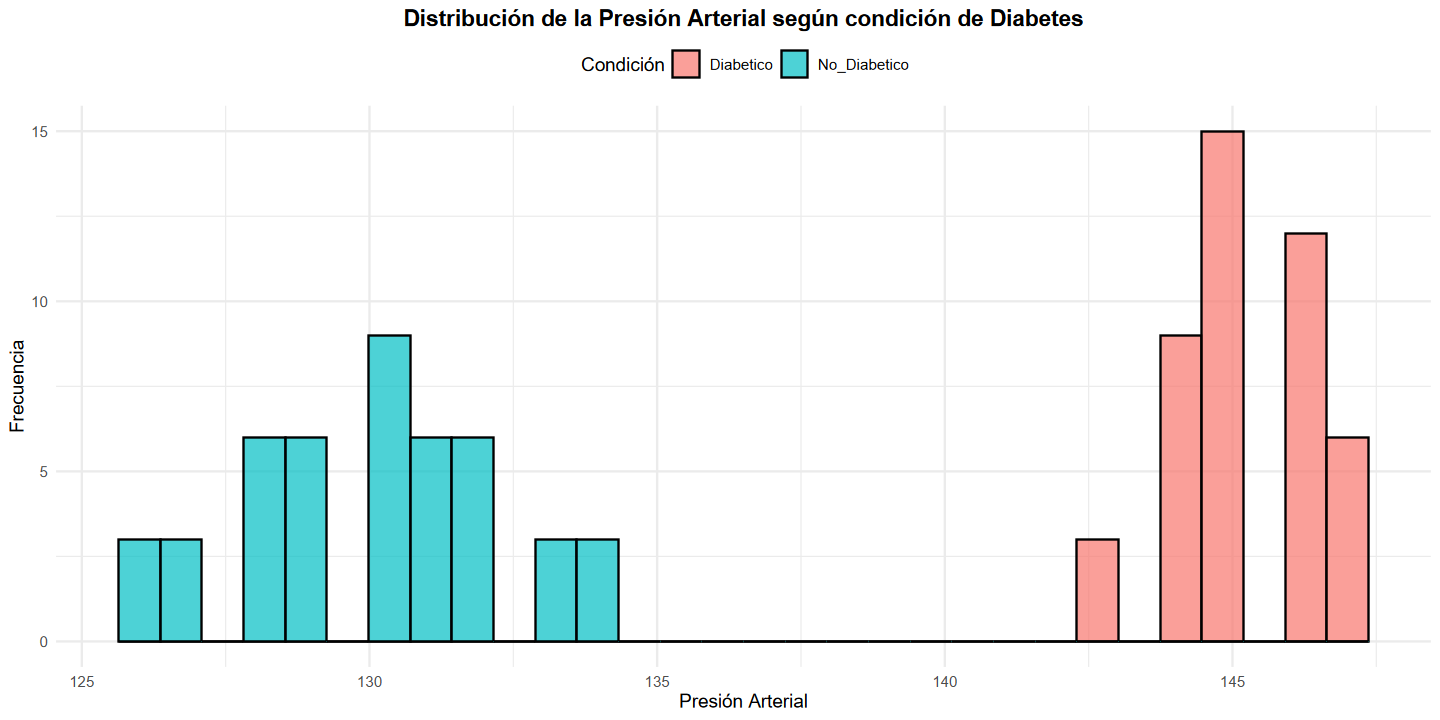

In [25]:

ggplot(datos, aes(x = Presion_Arterial, fill = Diabetes)) +
  geom_histogram(color = "black", bins = 30, alpha = 0.7, position = "identity") +
  labs(
    title = "Distribución de la Presión Arterial según condición de Diabetes",
    x = "Presión Arterial",
    y = "Frecuencia",
    fill = "Condición"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5),
    legend.position = "top"
  )





Confirmamos con la prueba de Mann-Whitney que hay diferencias significativas entre los grupos segmentados por condición diabética.

In [8]:
wilcox.test(Presion_Arterial ~ Diabetes, data = datos)

Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"cannot compute exact p-value with ties"



	Wilcoxon rank sum test with continuity correction

data:  Presion_Arterial by Diabetes
W = 2025, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0
